# Exploratory data analyses

## Introduction:

##### This notebook is about analyzing the **Final dataset**, which was created in the [02_final_data_preperation](../cleaning_part_2/02_final_data_preparation.ipynb) notebook, by creating different visualizations, analyzing important predefined hypothese and forming valuable assumptions which later to be used for the creation of the statistical models!

The notebook will follow a process, by examining the dataset features and analyzing hypotheses about the dataset.

#### **Hypotheses which will be analyzed:**
**H1:** Advanced latent performance metrics (such as expected goals, shots, and event-based statistics) provide a more accurate representation of team strength than raw match results.

**Sub-hypotheses that support this:**
- H1.1: Offensive quality dominates raw scoring \
Expected goals (xG) has higher predictive power for future results than goals scored and its a stronger estimator of attacking strength.

- H1.2: Separating attacking vs defensive \
Team strength can be decomposed into attacking and defensive components and remains relatively stable over short periods.

- H1.3: Defensive strength is stable and measurable \
Defensive performance (xG conceded, shots conceded) shows measurable consistency and contributes significantly to overall team strength.

- H1.4: Over/Underperformance Detection \
Persistent differences between goals scored and expected goals (xG) indicate overperformance or underperformance, reflecting randomness or finishing variance.

- H1.5: Context-adjusted performance is more informative than raw stats \
Home advantage, opponent strength, and match context significantly affect observed performance metrics.
The observation form these hypotheses is what we will have as a solid, realistic and data-justified performance strength, which we can use for the predictive models!

### Loading the required libraries:

In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch

import seaborn as sns

from football_betting_analysis.data.team_match_validation import validate_team_matches

### Loading the final dataset

In [3]:
final_df = pd.read_parquet('../../data/processed/processed_final_dataset.parquet')

In [4]:
final_df.columns

Index(['season', 'datetime', 'h_title', 'a_title', 'home_elo', 'away_elo',
       'home_form_last_5', 'away_form_last_5', 'home_goals_full',
       'away_goals_full', 'result_full', 'home_shots', 'away_shots',
       'home_shots_on_target', 'away_shots_on_target', 'home_fouls',
       'away_fouls', 'handicap_home', 'handicap_away', 'xG_h', 'xG_a',
       'odds_bet365_home', 'odds_bet365_draw', 'odds_bet365_away', 'goal_diff',
       'xG_diff', 'h_rolling_goals_5', 'h_rolling_goals_against_5',
       'h_rolling_shots_5', 'h_rolling_shots_against_5', 'h_rolling_sot_5',
       'h_rolling_sot_against_5', 'h_rolling_xG_5', 'h_rolling_xGA_5',
       'h_rolling_goal_diff_5', 'a_rolling_goals_5',
       'a_rolling_goals_against_5', 'a_rolling_shots_5',
       'a_rolling_shots_against_5', 'a_rolling_sot_5',
       'a_rolling_sot_against_5', 'a_rolling_xG_5', 'a_rolling_xGA_5',
       'a_rolling_goal_diff_5', 'h_h2h_rolling_goal_diff_5',
       'h_h2h_rolling_xG_diff_5', 'a_h2h_rolling_goal_diff

---

### Dataset prerequisites

Before making any visualizations and analyzes there should be checked some things. \
I want to validate the dataset for some inconsistencies or problems before the work to start just to make sure that everything is perfect:

#### Duplicates checking:

In [5]:
final_df.duplicated(
    subset=['datetime', 'h_title', 'a_title']
).sum()

np.int64(0)

#### Validating matches across the seasons

In [6]:
final_df['season'].value_counts()

season
2014/2015    380
2015/2016    380
2016/2017    380
2017/2018    380
2018/2019    380
2019/2020    380
2020/2021    380
2021/2022    380
2022/2023    380
2023/2024    380
2024/2025    380
Name: count, dtype: int64

#### Validating teams games across the seasons

In [7]:
result = validate_team_matches(data=final_df, home_team_title='h_title', away_team_title='a_title')

In [8]:
result

{'2014/2015': 20,
 '2015/2016': 20,
 '2016/2017': 20,
 '2017/2018': 20,
 '2018/2019': 20,
 '2019/2020': 20,
 '2020/2021': 20,
 '2021/2022': 20,
 '2022/2023': 20,
 '2023/2024': 20,
 '2024/2025': 20}

#### Checking for missing values

In [9]:
all(final_df.notna().all())

True

### Plots prerequisites

I will configure some initial settings to plots, which will define the standard way of ploting!

I want to specify that for the plotting, there will be used **MatPLotLib** as the main plotting library and **SeaBorn** for statistical plots and more beautiful visualizations!

In [10]:
plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["font.family"] = "DejaVu Sans"

sns.set_palette("deep")

#### Creating distributions

In this first section there will be mainly plot feature distributions as the purpose of this section is to understand the features distributions, identify some imbalances and eventually detect anomalies!

Ok now lets start by observing the distributions of the base dataset metrics as the goals, expected goals, elo ratings etc:

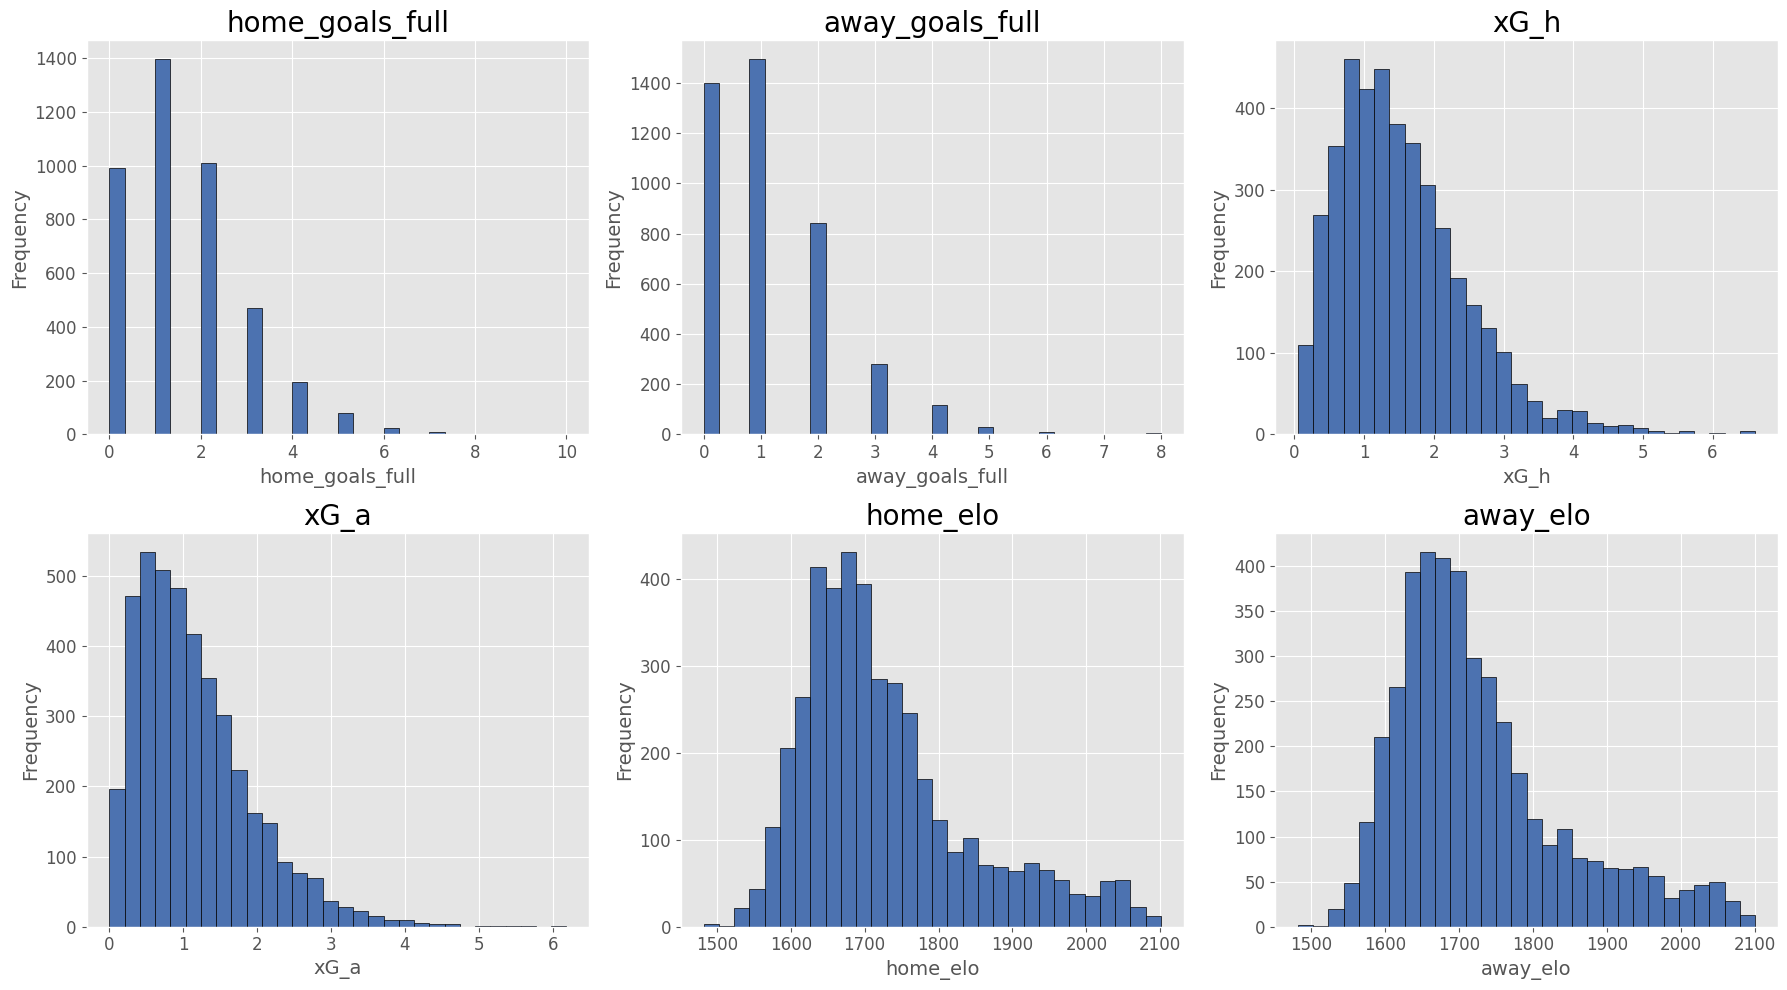

In [11]:
numerical_cols = [
    "home_goals_full",
    "away_goals_full",
    "xG_h",
    "xG_a",
    "home_elo",
    "away_elo"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for ax, col in zip(axes, numerical_cols):
    ax.hist(
        final_df[col],
        bins=30,
        edgecolor="black"
    )

    ax.set_title(f"{col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()

These distributions provide us with insights into the statistical structure of the dataset. Understanding skewness, variance, and concentration patterns helps determine whether transformations or normalization procedures may later be required for modeling.

From the home/away goals distributions it could be seen that the away teams tend to score less goals than the home teams.This can be clearly seen in the distributions.

Lets actually see how the matches outcomes(H(Home win), D(Draw), A(Away win)) are distributed.It is expected that the outcomes will be in favour of the home teams, which means that the home team are more likely to win a match than the away team!

#### Match Result Distribution

Plotting a bar plot which will show how the **wins vs draws vs losses** of the teams matches are distributed:

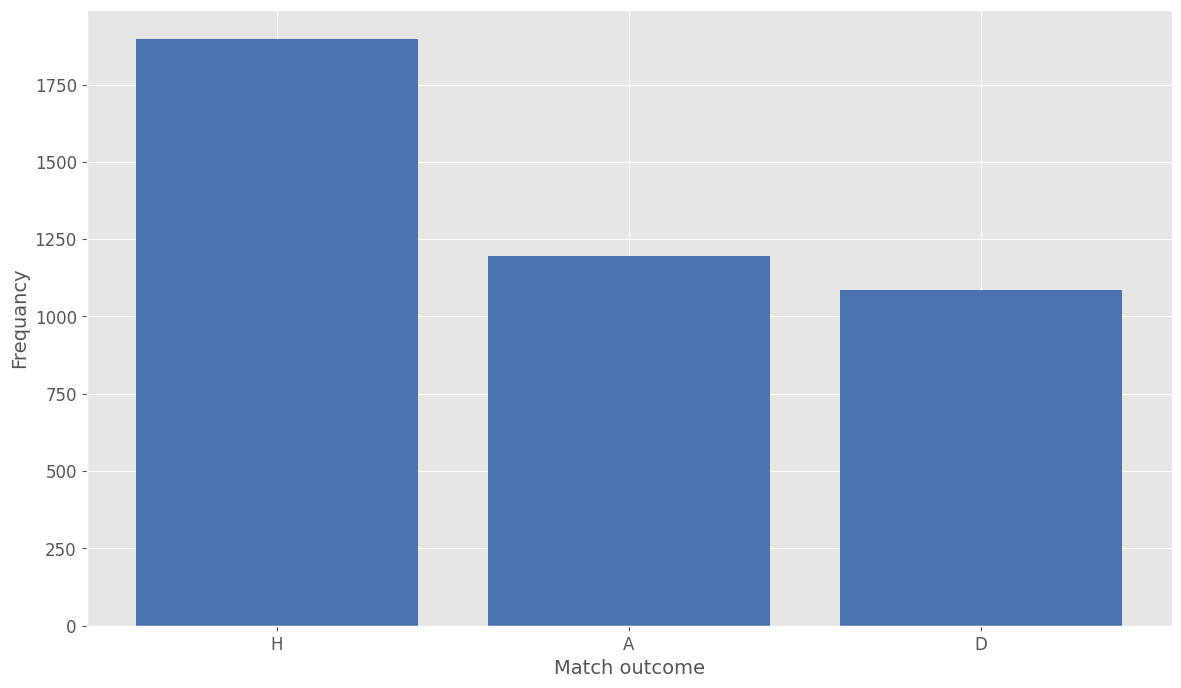

In [12]:
matches_results = final_df['result_full'].value_counts()

plt.bar(matches_results.index, matches_results.values)
plt.xlabel('Match outcome')
plt.ylabel('Frequancy')
plt.show()

#### We can see how much the outcomes of the matches are in favour to the home teams.
It is clearly that the home factor is a big advantage, which really influences the teams games!This is something we had formed from the first datasets understatndings, and now we can clearly see the home factor of a team playes as a big advantage to the teams and influence the matches outcomes!

#### Goal difference vs match outcomes

Goals, shots, and xG significantly influence match outcomes.

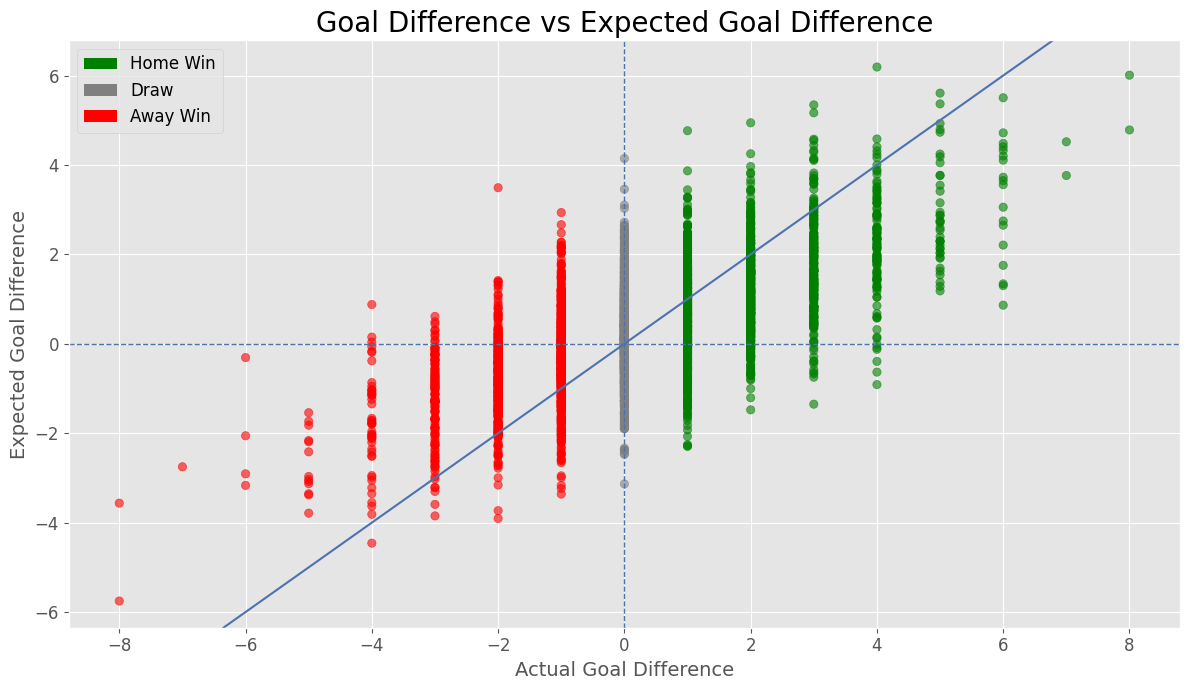

In [13]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = final_df["result_full"].map({
    "H": "green",
    "D": "gray",
    "A": "red"
})

scatter = ax.scatter(
    final_df["goal_diff"],
    final_df["xG_diff"],
    c=colors,
    alpha=0.6
)

ax.axhline(0, linestyle="--", linewidth=1)
ax.axvline(0, linestyle="--", linewidth=1)
ax.axline((0, 0), slope=1)

ax.set_title("Goal Difference vs Expected Goal Difference")
ax.set_xlabel("Actual Goal Difference")
ax.set_ylabel("Expected Goal Difference")

legend_elements = [
    Patch(facecolor="green", label="Home Win"),
    Patch(facecolor="gray", label="Draw"),
    Patch(facecolor="red", label="Away Win")
]

ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

##### Interpretation:

This plot compares actual match outcomes with underlying expected-goal performance. Matches far from the diagonal indicate overperformance or underperformance caused by finishing variance, randomness, or goalkeeping effects.

**Above the line:** A team created better chances than the scoreline reflects (under-performing their xG). They were likely unlucky or had poor finishing.

**Below the line:** A team scored more goals than their chance quality suggested (over-performing their xG). This suggests good finishing or "luck."

**On the line:** The result was a fair reflection of the chances created.

**Home Team Dominance**: Green dots in the top-right quadrant. This indicates the Home team created more/better chances than the Away team and converted them into a win.

**Away Team Dominance**: Red dots in the bottom-left quadrant. Since the axes are calculated as Home - Away, a negative value on both axes means the Away team had a higher xG and a better goal difference.

> Something which we can see is that, although most of the matches goall diffs overlap with the expected goals diffs, there is a significant amount of matches which are with strong difference between the actual goals and the expected goals- This could be seen in the top-left quadrant where the away teams have won the match, but the expected goals were not in their favour and in the bottom-right where the home teams have won the match, but the expected goals were not im their favour.This indicates inconsistencies between the actual goals outcome of the match and the exected ones - which also points that the football is a highly lucky game in which you can dominate all the time during a match, but the other team to beat you, all due to luck and unpredicatble sitiations!

Now something very interesting will be to see how the goals and expected goals are correlated and is there consistency in their relantionship:

### Expected goals analysis

#### xG vs Goals Correlation

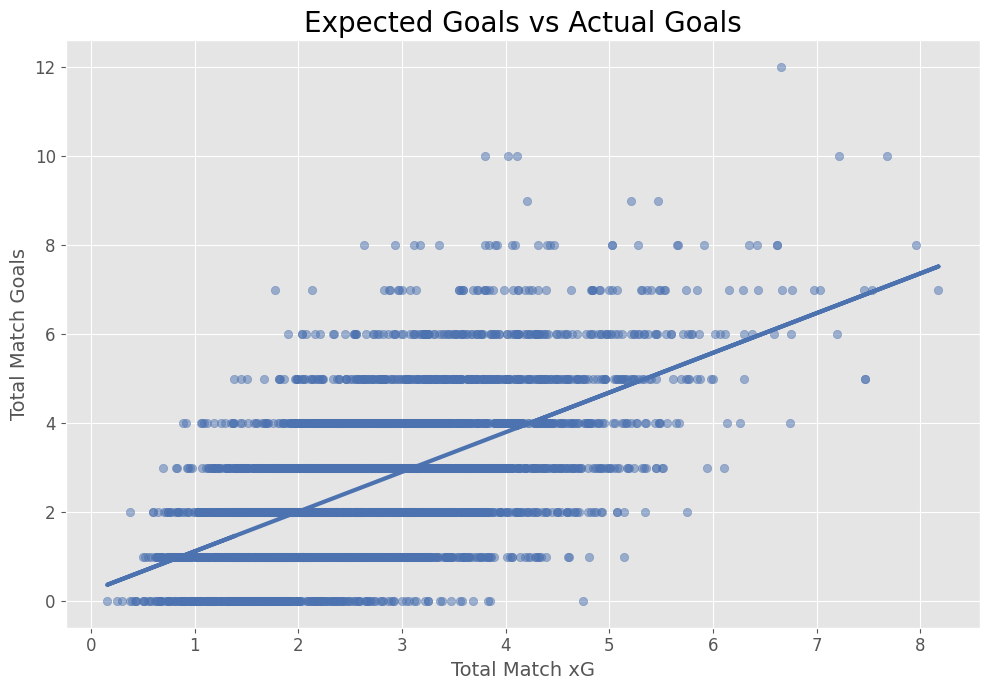

In [14]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    final_df["xG_h"] + final_df["xG_a"],
    final_df["home_goals_full"] + final_df["away_goals_full"],
    alpha=0.5
)

z = np.polyfit(
    final_df["xG_h"] + final_df["xG_a"],
    final_df["home_goals_full"] + final_df["away_goals_full"],
    1
)

p = np.poly1d(z)

ax.plot(
    final_df["xG_h"] + final_df["xG_a"],
    p(final_df["xG_h"] + final_df["xG_a"]),
    linewidth=3
)

ax.set_title("Expected Goals vs Actual Goals")
ax.set_xlabel("Total Match xG")
ax.set_ylabel("Total Match Goals")

plt.tight_layout()
plt.show()

##### Interpretation:
This plot shows whether expected goals reflect actual scoring outcomes. A strong positive relationship indicates that xG captures the true probability structure of football scoring opportunities better than raw shot counts.

What the plot shows: \
**The Scatter points**: Each point is one match. On the horizontal (X) is the total xG of both teams, and on the vertical (Y) – the total number of real goals.

**Trend line**: This is a linear regression line. It shows the general trend – whether as expected goals increase, actual goals also increase.

**Headlines**: Confirm the relationship between "Total Match xG" and "Total Match Goals".

From the plot we can see that the goals and the expected goals are not so clustered around the trend line.Now in order to see more detailed representation of a expected goals and goals correlation, I will limit the scope of the sample and analyze the rolling averages of a specific team, and identify if there is a strong relation between the goals and the expected goals over time!

#### Rolling xG Stability

Lets see how Barcelona is performing over time, and are the results of team corresponding to their actual play and matches real performance or not - This will show if the results of the teams matches are based on expected goals or not:

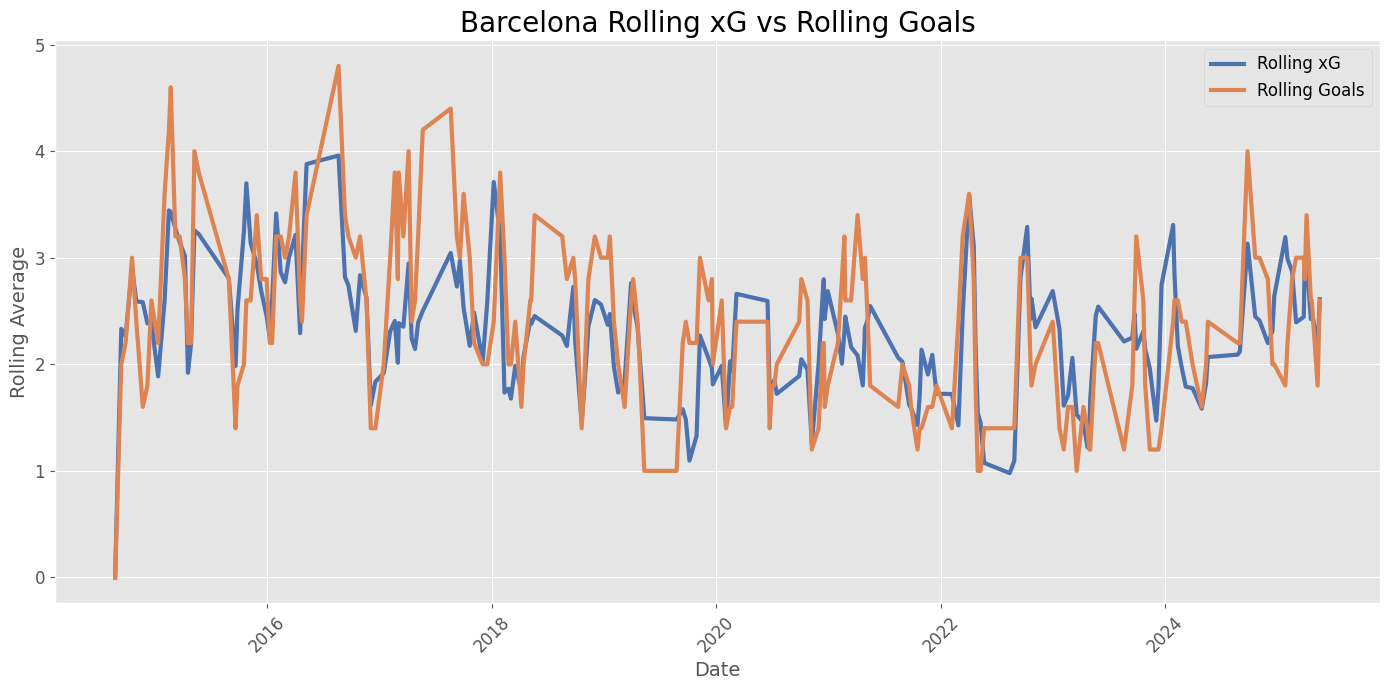

In [15]:
fig, ax = plt.subplots(figsize=(14, 7))

sample_team = "Barcelona"

team_df = final_df[final_df["h_title"] == sample_team]

ax.plot(
    team_df["datetime"],
    team_df["h_rolling_xG_5"],
    linewidth=3,
    label="Rolling xG"
)

ax.plot(
    team_df["datetime"],
    team_df["h_rolling_goals_5"],
    linewidth=3,
    label="Rolling Goals"
)

ax.set_title(f"{sample_team} Rolling xG vs Rolling Goals")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Average")

ax.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### Interpretation

This visualization compares the stability of expected goals and actual goals over time. xG tends to fluctuate less than goals because it captures chance quality rather than finishing randomness.

We can see that the team expected performance is roughly overlapping with its actual performance, which indicates that there is a strong relation between the teams goals scored and expected goals!

Now what I will do is that I will make the same plot, but this time the plot will clearly fill the zones wheer the team underperforms(Higher expected goals, lower actual goals) and where overperforming(Higher actual goals, lower expected goals)

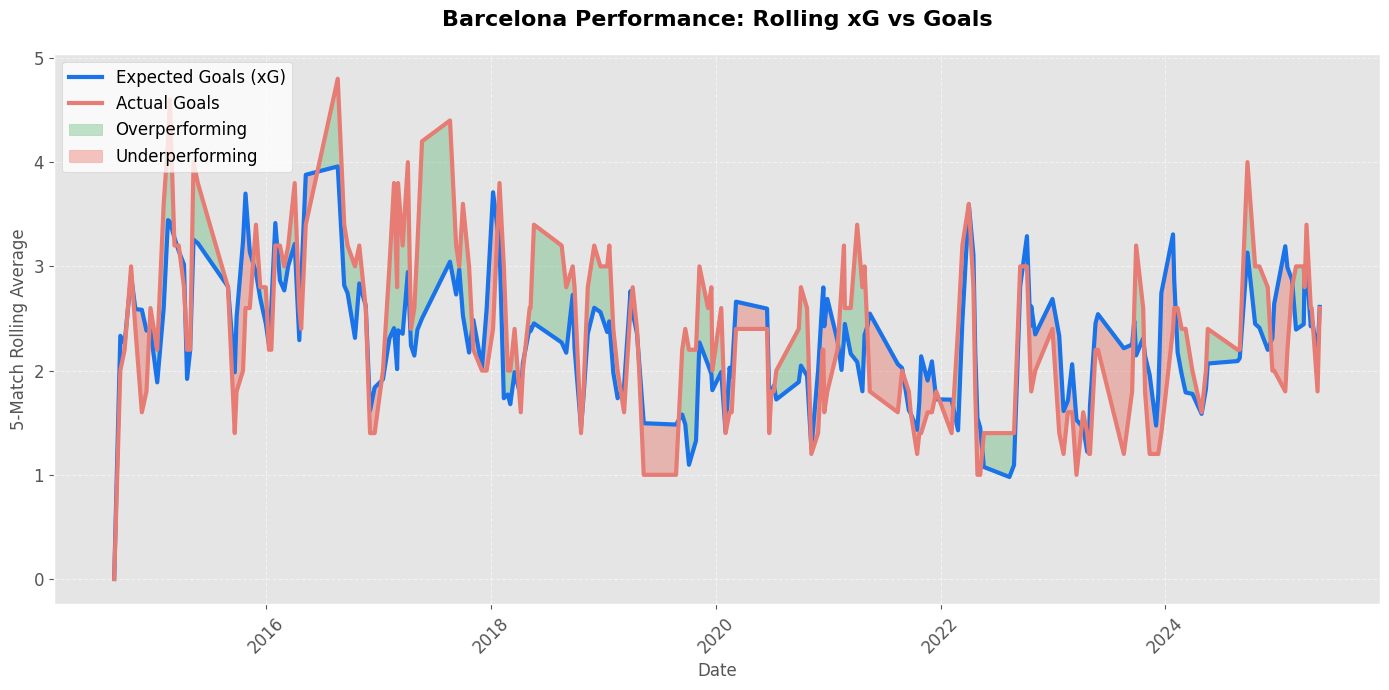

In [16]:
fig, ax = plt.subplots(figsize=(14, 7), dpi=100)
sample_team = "Barcelona"
team_df = final_df[final_df["h_title"] == sample_team]

# Using Zorder to ensure lines stay on top of the fills
ax.plot(
    team_df["datetime"], team_df["h_rolling_xG_5"], 
    color='#1a73e8', linewidth=3, label="Expected Goals (xG)", zorder=3
)
ax.plot(
    team_df["datetime"], team_df["h_rolling_goals_5"], 
    color='#e67c73', linewidth=3, label="Actual Goals", zorder=3
)

# Fill Green when Goals > xG (Team is clinical or lucky)
ax.fill_between(
    team_df["datetime"], team_df["h_rolling_goals_5"], team_df["h_rolling_xG_5"],
    where=(team_df["h_rolling_goals_5"] >= team_df["h_rolling_xG_5"]),
    interpolate=True, color='#34a853', alpha=0.3, label="Overperforming"
)

# Fill Red when Goals < xG (Team is wasteful or unlucky)
ax.fill_between(
    team_df["datetime"], team_df["h_rolling_goals_5"], team_df["h_rolling_xG_5"],
    where=(team_df["h_rolling_goals_5"] < team_df["h_rolling_xG_5"]),
    interpolate=True, color='#ea4335', alpha=0.3, label="Underperforming"
)

ax.set_title(f"{sample_team} Performance: Rolling xG vs Goals", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("5-Match Rolling Average", fontsize=12)


ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper left', frameon=True, facecolor='white')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Now it is clearly visible where the teams ups and downs are!

Now what I want to see is how the team performs during a single seasos.This is something interesting because, for team is normal to have lucky matches or bad days.But if we look at the team in a single season, it is expected that the performance will be overall normalized indicating strong relation between actual goals scored and expected goals!

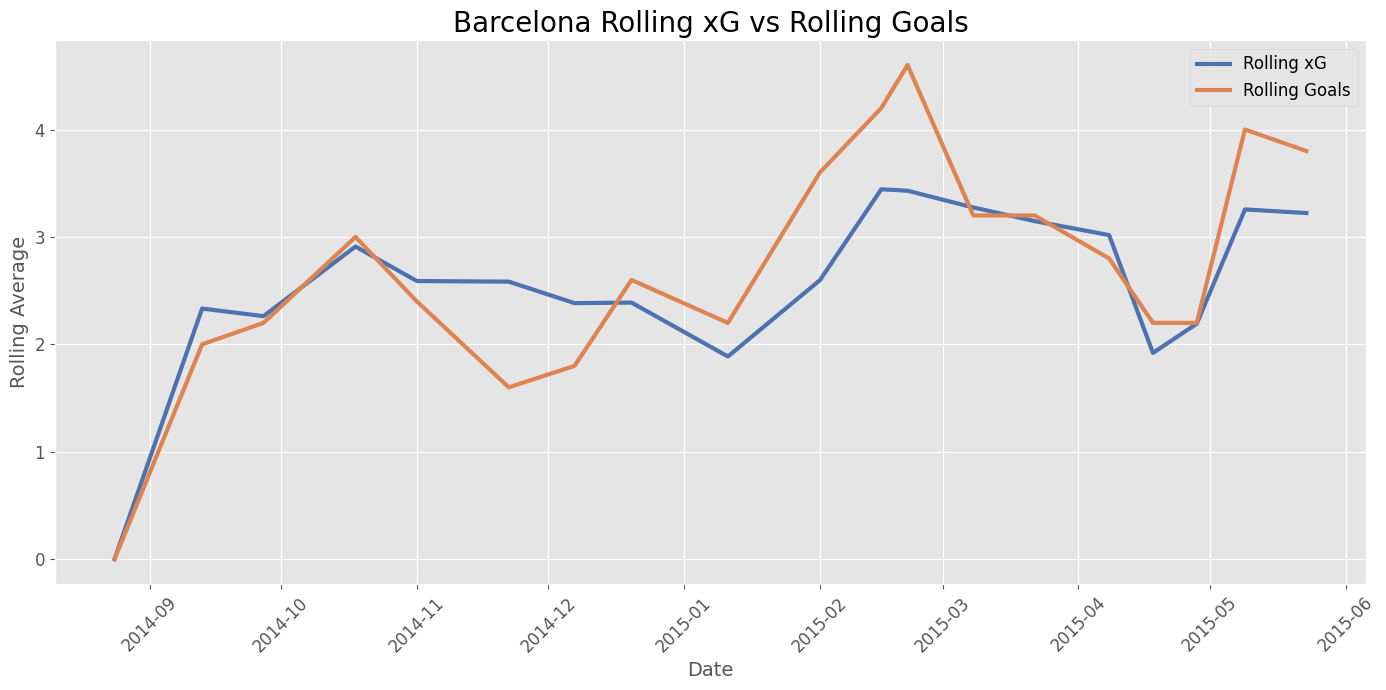

In [17]:
fig, ax = plt.subplots(figsize=(14, 7))

sample_team = "Barcelona"
season = '2014/2015'

team_df = final_df[
    (final_df["season"] == season) &
    (final_df["h_title"] == sample_team)
]

ax.plot(
    team_df["datetime"],
    team_df["h_rolling_xG_5"],
    linewidth=3,
    label="Rolling xG"
)

ax.plot(
    team_df["datetime"],
    team_df["h_rolling_goals_5"],
    linewidth=3,
    label="Rolling Goals"
)

ax.set_title(f"{sample_team} Rolling xG vs Rolling Goals")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Average")

ax.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Well, there are again some big ups and downs but overall it seems to be normalized!

Now as we are talking fro over and under performance lets create a plot which indicates excatly that:

#### Overperformance vs Underperformance:

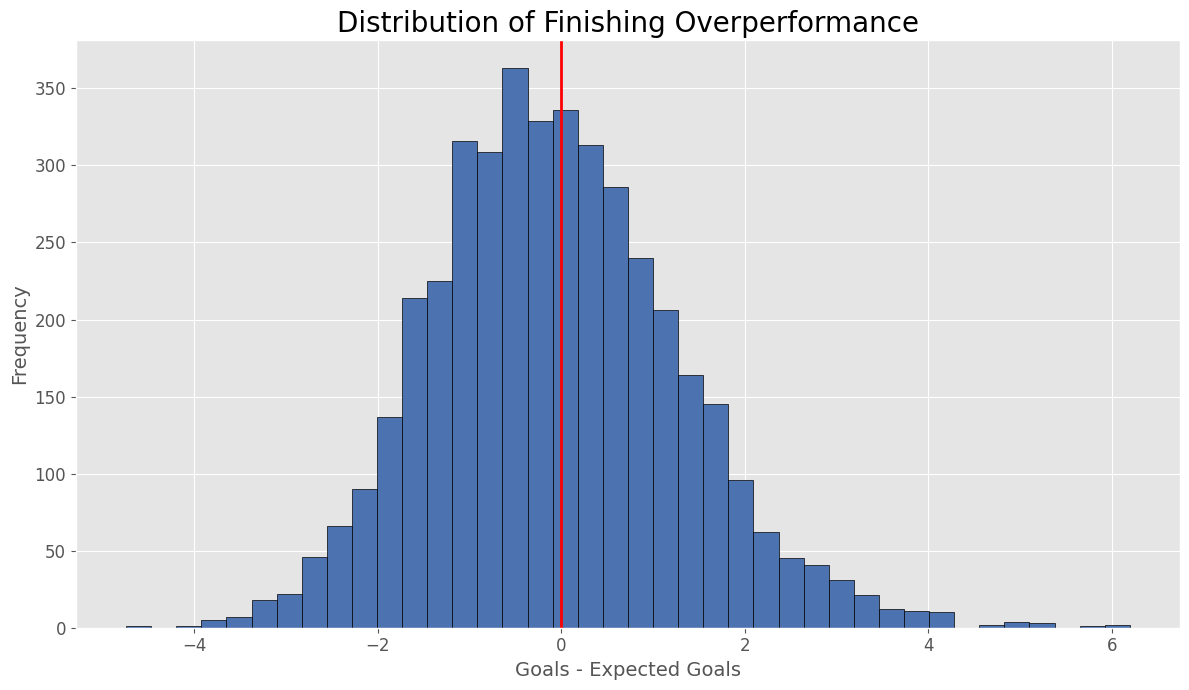

In [18]:
# Defining a performanse indicator which will help the plot show the performance incosistencies:
final_df["finishing_luck"] = (
    (final_df["home_goals_full"] + final_df["away_goals_full"]) -
    (final_df["xG_h"] + final_df["xG_a"])
)

fig, ax = plt.subplots(figsize=(12, 7))

ax.hist(
    final_df["finishing_luck"],
    bins=40,
    edgecolor="black"
)

ax.axvline(0, color="red", linewidth=2)

ax.set_title("Distribution of Finishing Overperformance")
ax.set_xlabel("Goals - Expected Goals")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Interpretation

Positive values indicate teams scoring above expectation, while negative values indicate underperformance. Persistent deviations may reveal elite finishing ability, poor finishing, or randomness.

Now what we can see from the plot, is that actually, more of the teams indicates strong relationships between there actual performance and the expected one, as most of the values are clustered around zero - This is good.On the other hand, the distribution is not strongly skewed, which indicates that as there are many teams which overperform, there are also as many which underperform!



Now something which I want to put big attention to is the **Home Advantage factor**.

##  Home advantage and context

We already saw how the matches were distributed based on their outcomes, but lets now see how the matches outcomes are distributed in percentages!

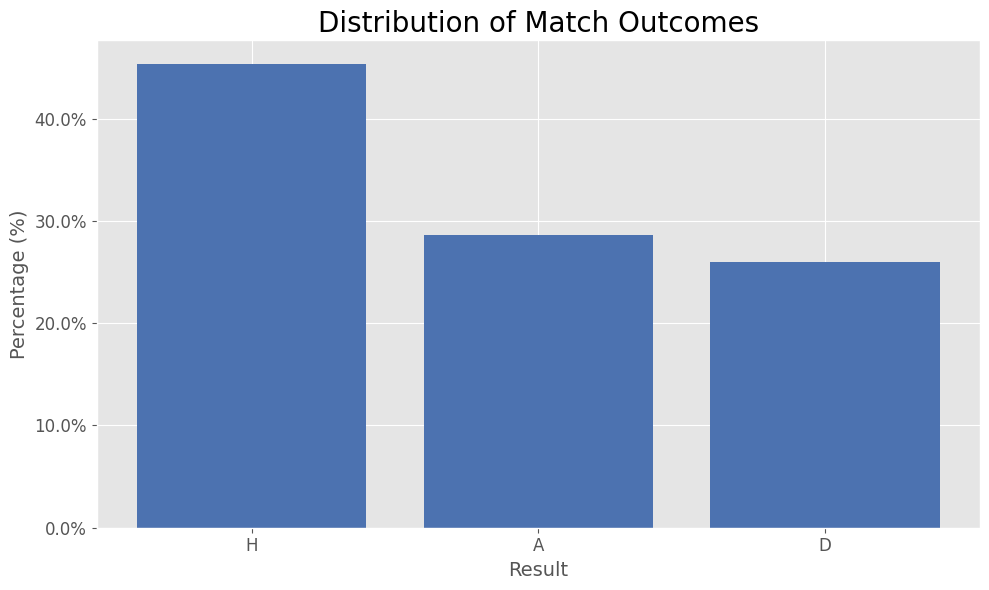

In [19]:
result_counts = final_df["result_full"].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    result_counts.index,
    result_counts.values * 100
)

ax.set_title("Distribution of Match Outcomes")
ax.set_xlabel("Result")
ax.set_ylabel("Percentage (%)")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

#### Interpratation

This visualization evaluates the existence and magnitude of home advantage. Consistent home-win dominance indicates structural contextual effects influencing football outcomes.

More than 40 percent of the matches are won by the home teams.This again underlines the big factor which the home advantage have over the matches outcomes!

---

#### Now I will continue by evaluateing whether **rating systems**(The elo ratings metrics) capture true team strength.

### Elo Difference vs Win Probability

I will do the ame scatter plot as I did for the expected goals and actual goals differences and I will create a trand line, which represent the liner regression elo ratings and the goals differences!

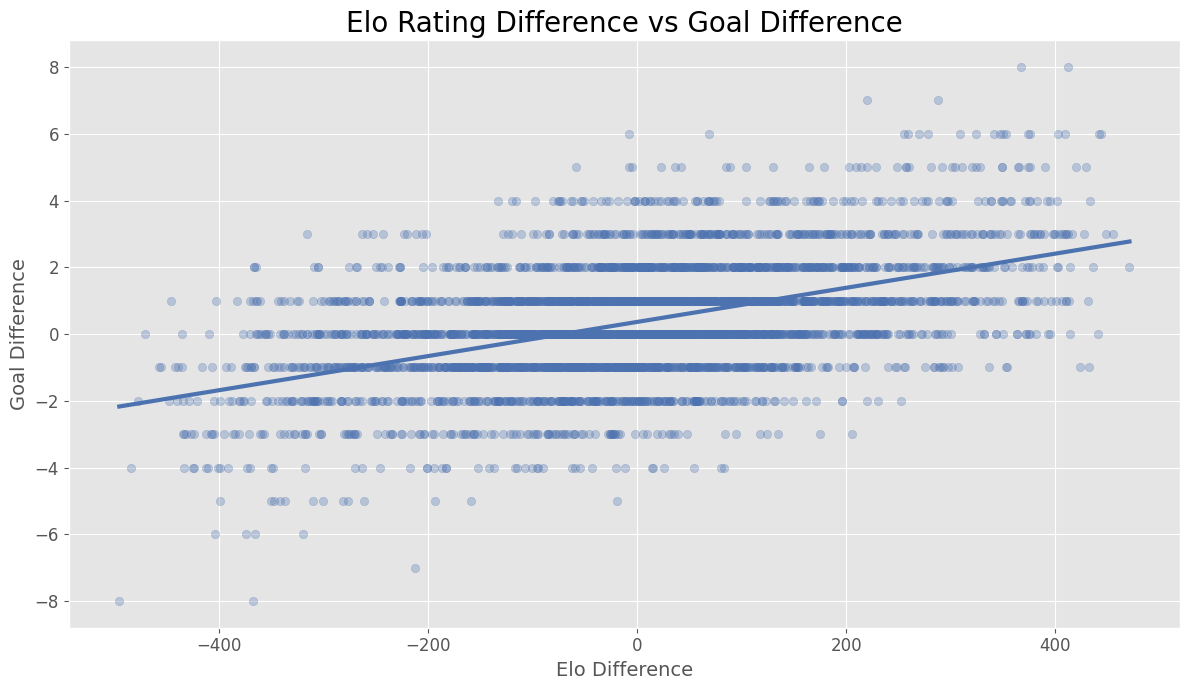

In [20]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    final_df["elo_rating_diff"],
    final_df["goal_diff"],
    alpha=0.3
)

z = np.polyfit(
    final_df["elo_rating_diff"],
    final_df["goal_diff"],
    1
)

p = np.poly1d(z)

x = np.linspace(
    final_df["elo_rating_diff"].min(),
    final_df["elo_rating_diff"].max(),
    100
)

ax.plot(
    x,
    p(x),
    linewidth=3
)

ax.set_title("Elo Rating Difference vs Goal Difference")
ax.set_xlabel("Elo Difference")
ax.set_ylabel("Goal Difference")

plt.tight_layout()
plt.show()

#### Interpretation:

This plot evaluates whether rating systems capture true team strength. Strong correlation supports the validity of Elo-based predictive systems.

Well we can see that there is a visiale relation between the elo ratings differences and the goals differences.

---

#### Now the most important thing that should be analyzed, and which is part of the most important hypothesis of the project is: **Market Efficiency**

### **Market Efficiency**

> Betting markets efficiently price football outcomes.

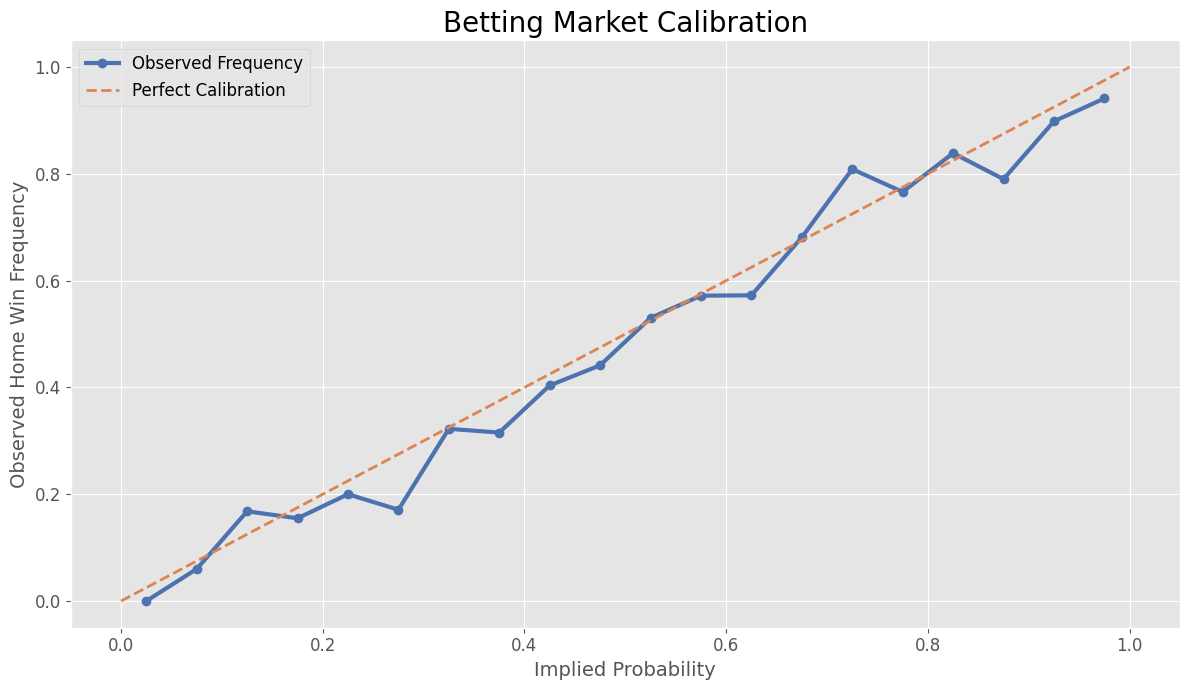

In [21]:
final_df["market_home_prob"] = 1 / final_df["odds_bet365_home"]

bins = np.arange(0, 1.05, 0.05)

final_df["prob_bin"] = pd.cut(
    final_df["market_home_prob"],
    bins
)

calibration = final_df.groupby("prob_bin").apply(
    lambda x: (x["result_full"] == "H").mean()
)

fig, ax = plt.subplots(figsize=(12, 7))

bin_centers = bins[:-1] + 0.025

ax.plot(
    bin_centers,
    calibration.values,
    marker="o",
    linewidth=3,
    label="Observed Frequency"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Perfect Calibration"
)

ax.set_title("Betting Market Calibration")
ax.set_xlabel("Implied Probability")
ax.set_ylabel("Observed Home Win Frequency")

ax.legend()

plt.tight_layout()
plt.show()

#### Interpretation

This is one of the most important analyses in the project. It evaluates whether bookmaker probabilities accurately reflect true outcome frequencies. \
Any deviation from the diagonal indicates market inefficiency.

What the plot is showing, is that the market is generally consistent at its predictions, but there are visible deviations, which indicates that the market is no perfect!Such deviations are acceptable, as the football is a high dinamic, inconsistent and most of the times very surprising game.

---

#### Now as lastly, I want to analyze more detaily the relationships between the dataset features and either identify highly predictive variables or laten relationships.

## Feature relationships:

I will start by creating a correlation heatmap, which will show if there are correlations between the features!

The following features will be used for the analysis:

In [22]:
corr_features = [
    "home_elo",
    "away_elo",
    "xG_h",
    "xG_a",
    "goal_diff",
    "xG_diff",
    "home_shots_on_target",
    "away_shots_on_target",
    "h_rolling_xG_5",
    "a_rolling_xG_5"
]

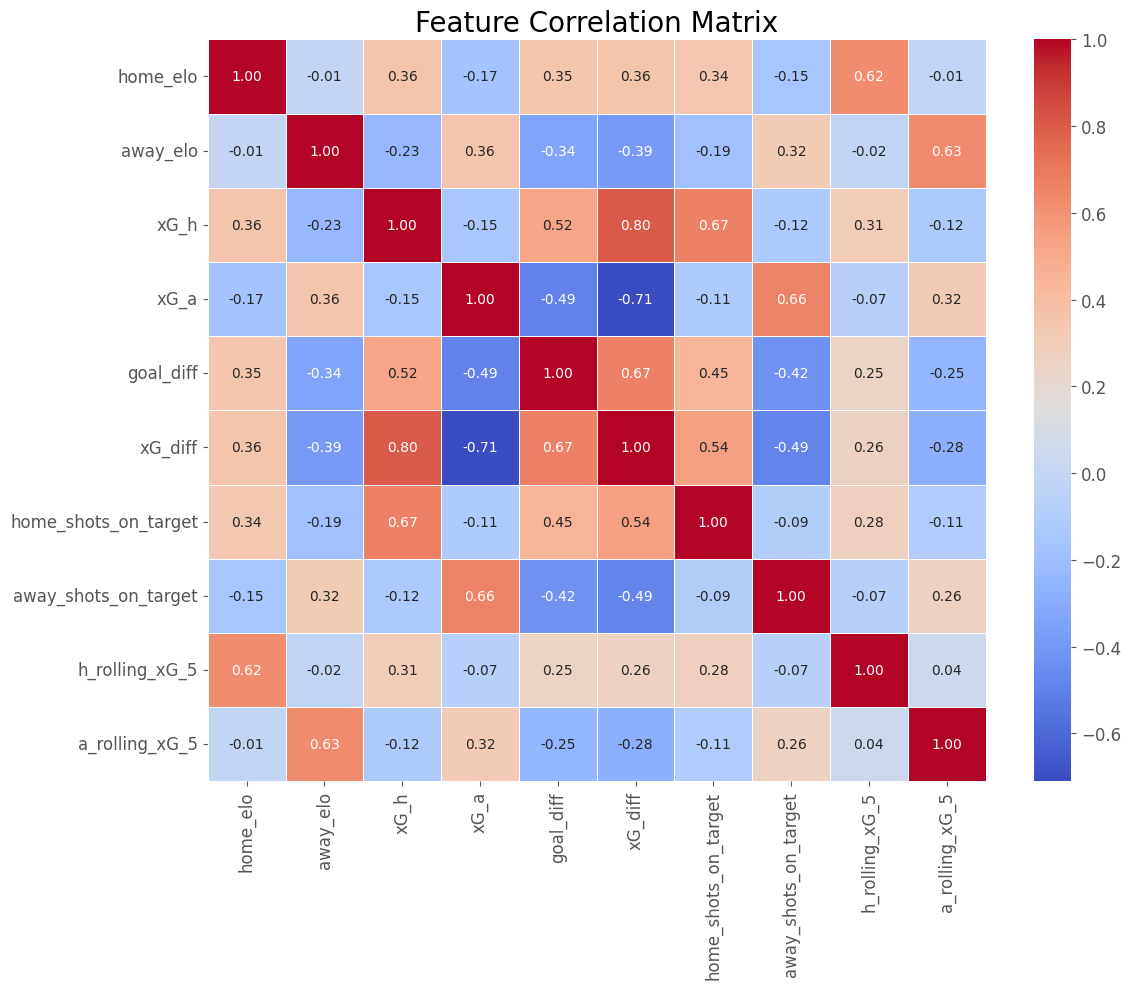

In [23]:
corr_matrix = final_df[corr_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()